<div style="background: #d9004c; 
            padding: 25px; 
            border-radius: 15px; 
            text-align: center;
            box-shadow: 3px 3px 15px rgba(0,0,0,0.2);">
    <h1 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Digital Image Processing
    </h1>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Topic: Noise and Its Types
    </h3>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Notebook by - Himel Sarder
    </h3>
    <p style="font-family: 'Verdana', sans-serif; color: #ffffffcc; font-size: 16px; text-align: center">
        info.himelcse@gmail.com
    </p>
</div>

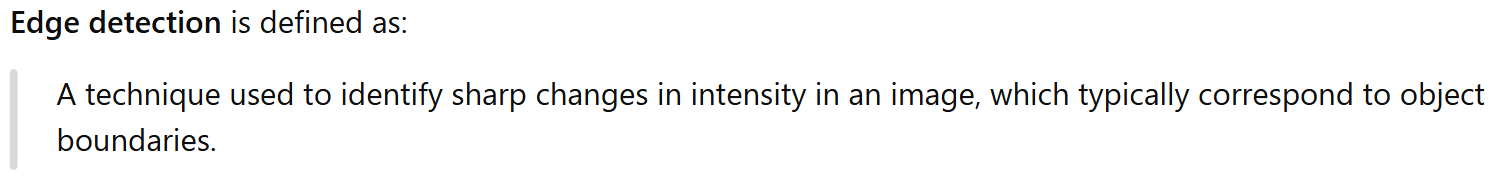
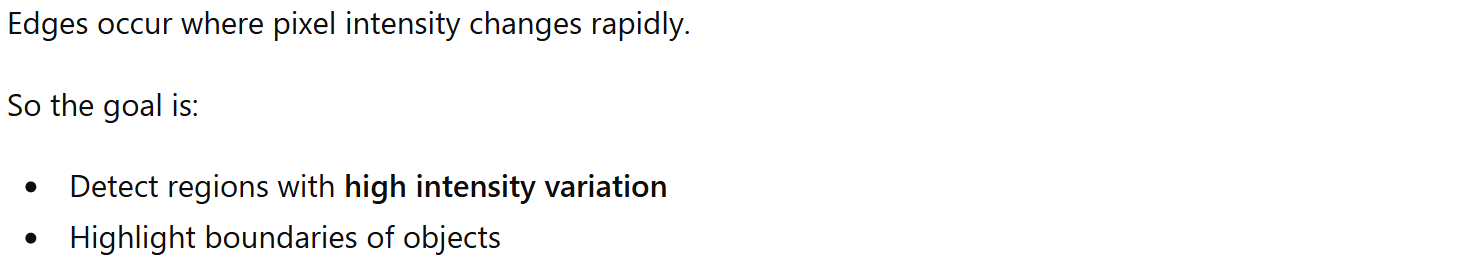
## Gradient Concept
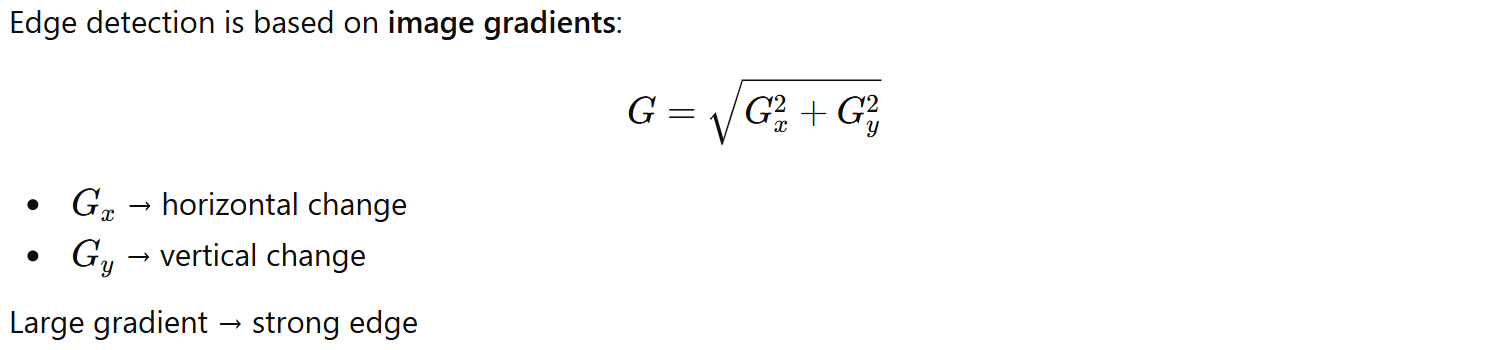
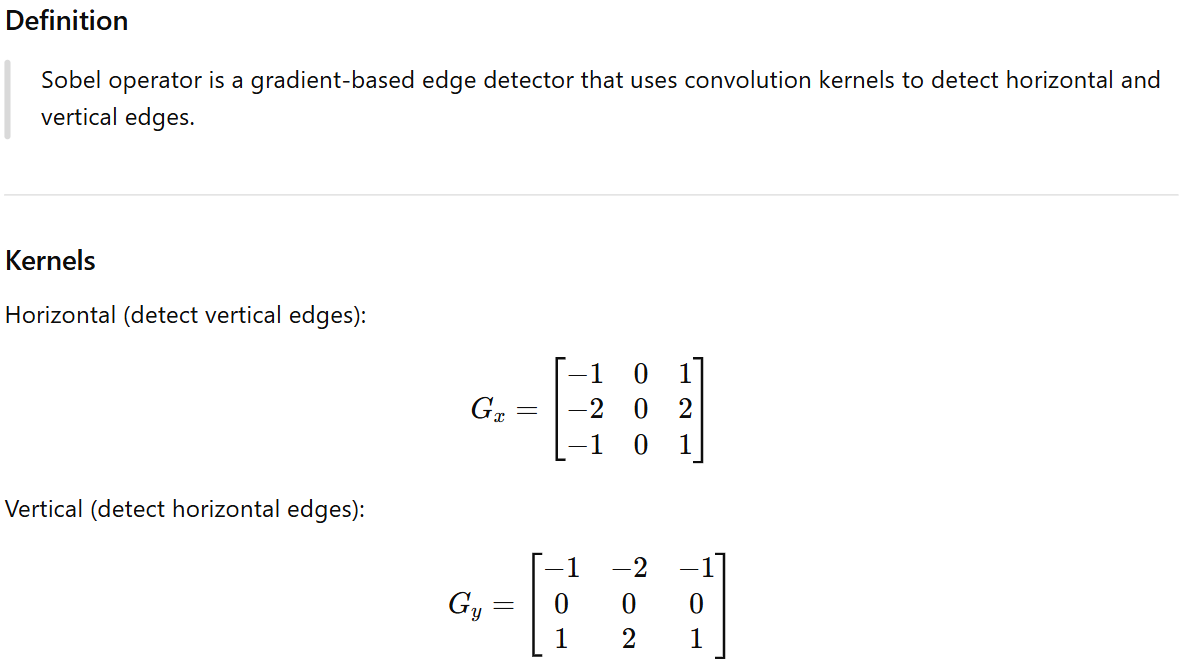

In [1]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

In [2]:
sobel_combined = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

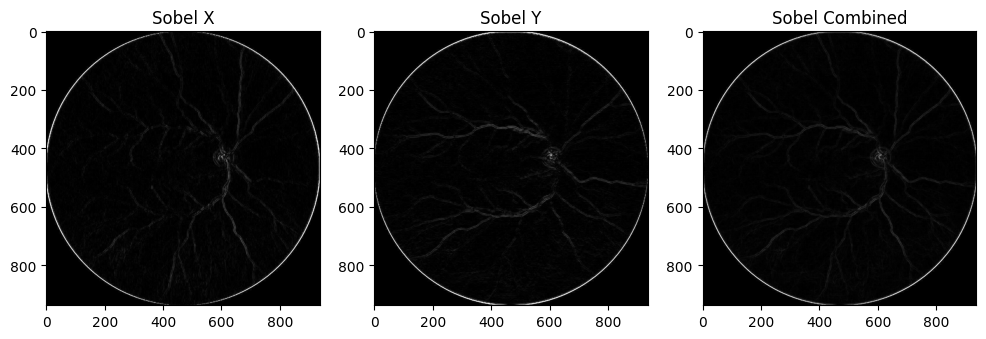

In [3]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(sobel_x, cmap='gray')
plt.title('Sobel X')

plt.subplot(1,3,2)
plt.imshow(sobel_y, cmap='gray')
plt.title('Sobel Y')

plt.subplot(1,3,3)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Combined')

plt.show()

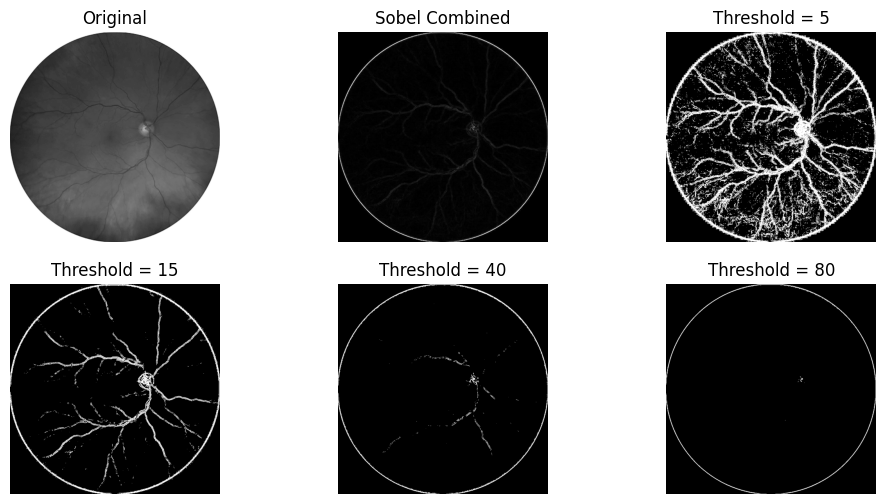

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

# Sobel
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

# Convert to uint8 (VERY IMPORTANT)
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

# Combine
sobel_combined = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

# Threshold tuning
_, edges1 = cv2.threshold(sobel_combined, 5, 255, cv2.THRESH_BINARY)
_, edges2 = cv2.threshold(sobel_combined, 15, 255, cv2.THRESH_BINARY)
_, edges3 = cv2.threshold(sobel_combined, 40, 255, cv2.THRESH_BINARY)
_, edges4 = cv2.threshold(sobel_combined, 80, 255, cv2.THRESH_BINARY)

# Plot
plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Combined')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(edges1, cmap='gray')
plt.title('Threshold = 5')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(edges2, cmap='gray')
plt.title('Threshold = 15')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(edges3, cmap='gray')
plt.title('Threshold = 40')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(edges4, cmap='gray')
plt.title('Threshold = 80')
plt.axis('off')

plt.show()

## Auto Threshold

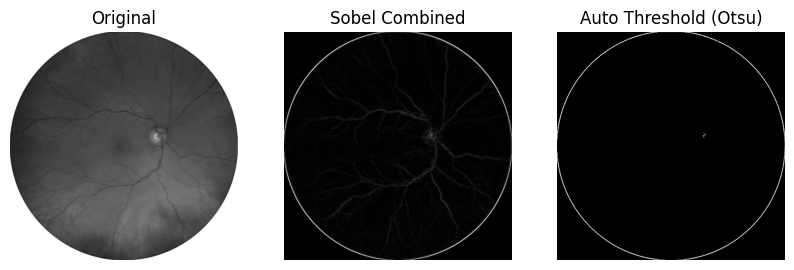

In [5]:
# Load image
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

# Sobel
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

# Convert
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

# Combine
sobel_combined = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

# Auto threshold
_, edges_auto = cv2.threshold(
    sobel_combined, 
    0, 
    255, 
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Combined')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(edges_auto, cmap='gray')
plt.title('Auto Threshold (Otsu)')
plt.axis('off')

plt.show()

# Prewitt Operator
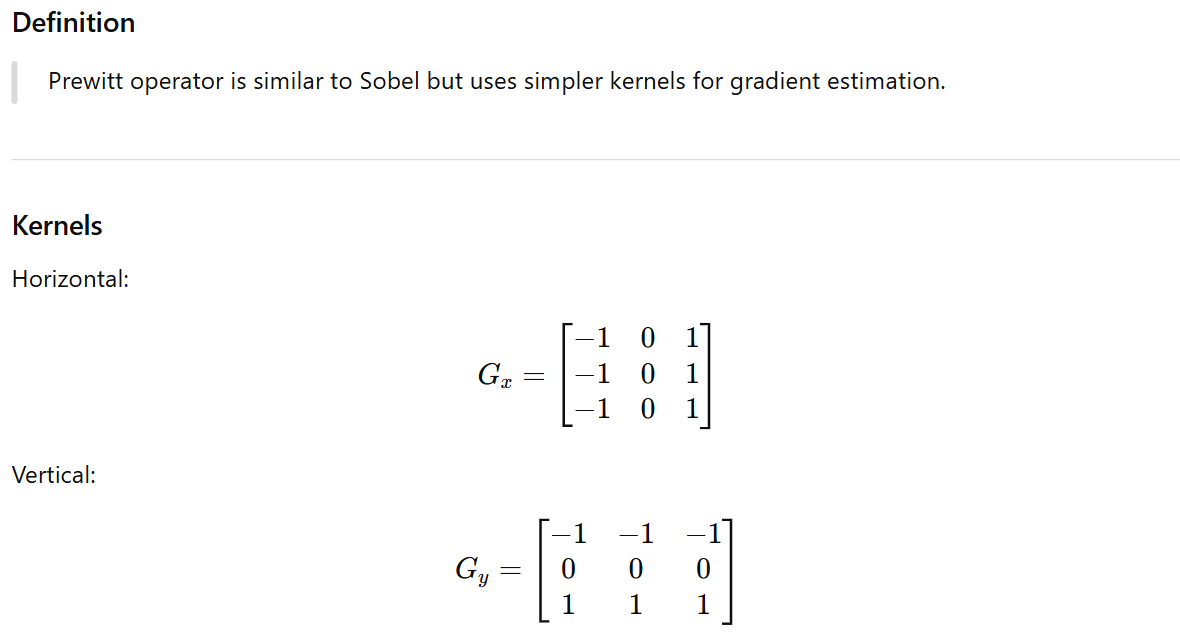

In [6]:
import numpy as np

kernel_x = np.array([[-1,0,1],
                     [-1,0,1],
                     [-1,0,1]])

kernel_y = np.array([[-1,-1,-1],
                     [0,0,0],
                     [1,1,1]])

prewitt_x = cv2.filter2D(image, -1, kernel_x)
prewitt_y = cv2.filter2D(image, -1, kernel_y)

prewitt = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

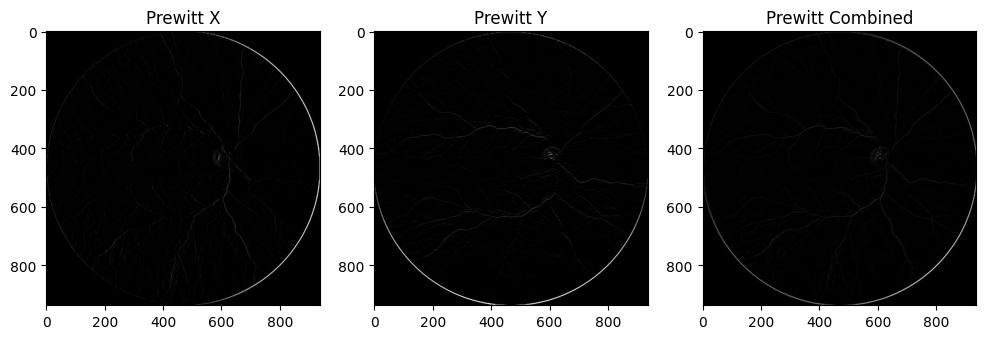

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(prewitt_x, cmap='gray')
plt.title('Prewitt X')

plt.subplot(1,3,2)
plt.imshow(prewitt_y, cmap='gray')
plt.title('Prewitt Y')

plt.subplot(1,3,3)
plt.imshow(prewitt, cmap='gray')
plt.title('Prewitt Combined')

plt.show()

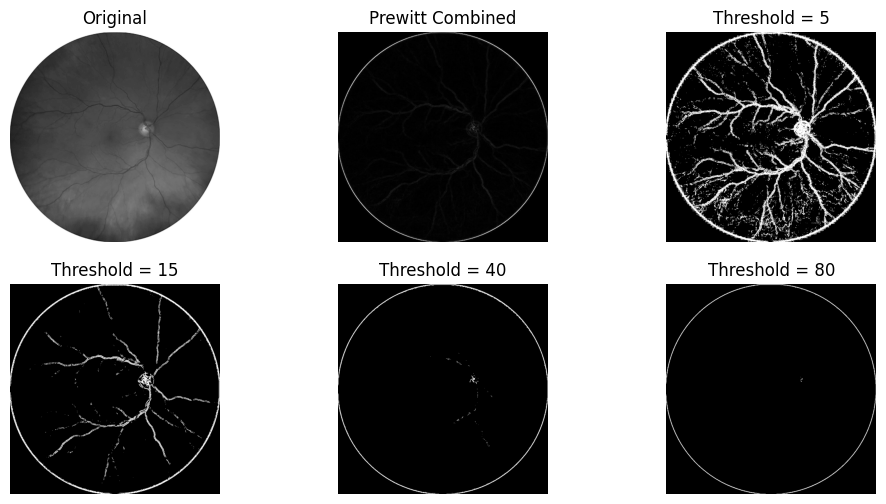

In [8]:
# Load image
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

# 🔹 Prewitt kernels
kernel_x = np.array([[-1, 0, 1],
                     [-1, 0, 1],
                     [-1, 0, 1]])

kernel_y = np.array([[-1, -1, -1],
                     [ 0,  0,  0],
                     [ 1,  1,  1]])

# Apply Prewitt
prewitt_x = cv2.filter2D(image, cv2.CV_64F, kernel_x)
prewitt_y = cv2.filter2D(image, cv2.CV_64F, kernel_y)

# Convert to uint8 
prewitt_x = cv2.convertScaleAbs(prewitt_x)
prewitt_y = cv2.convertScaleAbs(prewitt_y)

# Combine
prewitt_combined = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

# Threshold tuning 
_, edges1 = cv2.threshold(prewitt_combined, 5, 255, cv2.THRESH_BINARY)
_, edges2 = cv2.threshold(prewitt_combined, 15, 255, cv2.THRESH_BINARY)
_, edges3 = cv2.threshold(prewitt_combined, 40, 255, cv2.THRESH_BINARY)
_, edges4 = cv2.threshold(prewitt_combined, 80, 255, cv2.THRESH_BINARY)

# Plot
plt.figure(figsize=(12,6))

plt.subplot(2,3,1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(prewitt_combined, cmap='gray')
plt.title('Prewitt Combined')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(edges1, cmap='gray')
plt.title('Threshold = 5')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(edges2, cmap='gray')
plt.title('Threshold = 15')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(edges3, cmap='gray')
plt.title('Threshold = 40')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(edges4, cmap='gray')
plt.title('Threshold = 80')
plt.axis('off')

plt.show()

## Auto Threshold

Otsu Threshold = 67.0


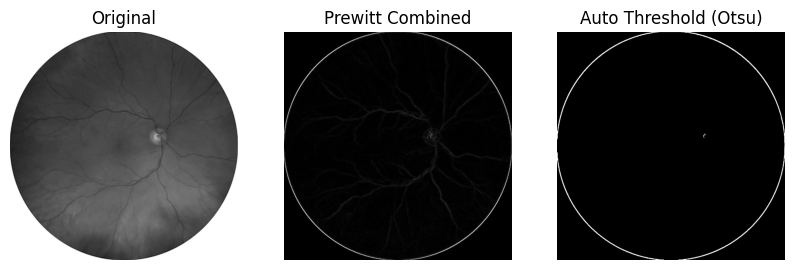

In [9]:
# Load image
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

# Prewitt kernels
kernel_x = np.array([[-1, 0, 1],
                     [-1, 0, 1],
                     [-1, 0, 1]])

kernel_y = np.array([[-1, -1, -1],
                     [ 0,  0,  0],
                     [ 1,  1,  1]])

# Apply Prewitt
prewitt_x = cv2.filter2D(image, cv2.CV_64F, kernel_x)
prewitt_y = cv2.filter2D(image, cv2.CV_64F, kernel_y)

# Convert to uint8
prewitt_x = cv2.convertScaleAbs(prewitt_x)
prewitt_y = cv2.convertScaleAbs(prewitt_y)

# Combine
prewitt_combined = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

# Blur (better Otsu result)
blur = cv2.GaussianBlur(prewitt_combined, (5,5), 0)

# Auto Threshold (Otsu)
thresh_value, edges_auto = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu Threshold =", thresh_value)

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(prewitt_combined, cmap='gray')
plt.title('Prewitt Combined')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(edges_auto, cmap='gray')
plt.title('Auto Threshold (Otsu)')
plt.axis('off')

plt.show()